# Project Update #2: YOLOv7 Fine-Tuning — Training
## Gym Equipment Object Detection

**Team Members:** Varun Gazala | Mohit Raiyani | Jatinkumar Nabhoya  
**University of New Haven | Spring 2026**

**Paper:** [arXiv:2207.02696](https://arxiv.org/abs/2207.02696)  
**Repository:** [WongKinYiu/yolov7](https://github.com/WongKinYiu/yolov7)

---

### Phase 2 Goals
1. Fine-tune the modified YOLOv7 head (5 gym equipment classes) using the training strategy from the paper
2. **Freeze backbone** for the first 5 epochs → then unfreeze and train end-to-end
3. **SGD** optimizer with linear warmup + cosine LR decay ("trainable bag-of-freebies" schedule)
4. Track train/val loss and val mAP@0.5 per epoch
5. Save `best.pt` whenever val mAP@0.5 improves

### Contents
1. Environment Setup
2. Configuration
3. Dataset & DataLoaders (GymEquipmentDataset)
4. Model — Load & Modify for 5 Classes
5. Training Setup (Optimizer, LR Schedule)
6. Training Loop (50 Epochs)
7. Loss Curves
8. mAP Curve
9. Predictions on Validation Images
10. Summary

---
# 1. Environment Setup

In [4]:
# Clone YOLOv7 and install dependencies (skip if already done)
import os

if not os.path.exists('../yolov7'):
    !git clone https://github.com/WongKinYiu/yolov7.git ../yolov7
%cd ../yolov7

!pip install -q matplotlib numpy opencv-python Pillow PyYAML scipy torch torchvision \
               tqdm pandas seaborn torchmetrics pycocotools scikit-learn

if not os.path.exists('../yolov7'):
    !curl -L -o yolov7.pt https://github.com/WongKinYiu/yolov7/releases/download/v0.1/yolov7.pt
    print('Downloaded yolov7.pt')
else:
    print('yolov7.pt already present')

/Users/jatinnabhoya/Desktop/UNH/Semester 3/Deep Learning /Project/yolov7
yolov7.pt already present


---
# 2. Imports & Configuration

In [28]:
%matplotlib inline

import sys, os, glob, math, random, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
warnings.filterwarnings('ignore')

# YOLOv7 imports (must be run from yolov7/ directory)
sys.path.insert(0, '../yolov7')
from models.experimental import attempt_load
from utils.general import non_max_suppression, xywh2xyxy
from utils.torch_utils import select_device
from utils.datasets import letterbox
from utils.loss import ComputeLoss

device = select_device('')  # auto: CUDA > MPS > CPU
print(f'Device: {device}')

Device: cpu


In [6]:
# ─── Configuration ───
NUM_CLASSES  = 5
CLASS_NAMES  = ['dumbbell', 'barbell', 'kettlebell', 'resistance_band', 'pull_up_bar']
CLASS_COLORS = [
    (0.85, 0.32, 0.32),   # dumbbell      — red
    (0.30, 0.69, 0.29),   # barbell       — green
    (0.22, 0.46, 0.82),   # kettlebell    — blue
    (0.93, 0.69, 0.13),   # resistance_band — gold
    (0.58, 0.26, 0.81),   # pull_up_bar   — purple
]

IMG_SIZE      = 640
BATCH_SIZE    = 8
NUM_EPOCHS    = 50
FREEZE_EPOCHS = 5       # freeze backbone for first N epochs
WARMUP_EPOCHS = 3       # linear LR warmup
LR_INIT       = 0.01    # SGD base learning rate
MOMENTUM      = 0.937
WEIGHT_DECAY  = 5e-4
RANDOM_SEED   = 42

DATASET_ROOT  = '../dataset'   # one level up from yolov7/
BEST_PT       = 'best.pt'

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print('Configuration loaded.')
print(f'  Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'  Epochs: {NUM_EPOCHS}  |  Freeze backbone: first {FREEZE_EPOCHS} epochs')
print(f'  LR={LR_INIT}, momentum={MOMENTUM}, weight_decay={WEIGHT_DECAY}')

Configuration loaded.
  Classes (5): ['dumbbell', 'barbell', 'kettlebell', 'resistance_band', 'pull_up_bar']
  Epochs: 50  |  Freeze backbone: first 5 epochs
  LR=0.01, momentum=0.937, weight_decay=0.0005


---
# 3. Dataset & DataLoaders

`GymEquipmentDataset` reads YOLO-format labels, applies HSV jitter + random flip augmentation
(training only), and letterbox-resizes to 640×640.  
`collate_fn` prepends the batch index to each target row so YOLOv7's `ComputeLoss` knows
which image each box belongs to.

**Target format:** `[batch_idx, class_id, x_center, y_center, w, h]` (all normalized 0–1)

In [7]:
class GymEquipmentDataset(Dataset):
    """YOLO-format gym equipment dataset with optional augmentation."""

    def __init__(self, images_dir, labels_dir, img_size=640, augment=False):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.img_size   = img_size
        self.augment    = augment

        self.img_files = sorted(glob.glob(os.path.join(images_dir, '*.*')))
        self.img_files = [f for f in self.img_files
                          if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        assert len(self.img_files) > 0, f'No images found in {images_dir}'

        self.labels = []
        for img_path in self.img_files:
            lbl_path = os.path.join(labels_dir, Path(img_path).stem + '.txt')
            if os.path.exists(lbl_path):
                rows = []
                with open(lbl_path) as f:
                    for line in f:
                        p = line.strip().split()
                        if len(p) == 5:
                            rows.append([int(p[0])] + [float(x) for x in p[1:]])
                self.labels.append(np.array(rows, dtype=np.float32)
                                   if rows else np.zeros((0, 5), dtype=np.float32))
            else:
                self.labels.append(np.zeros((0, 5), dtype=np.float32))

        total = sum(len(l) for l in self.labels)
        print(f'  {len(self.img_files)} images, {total} annotations  [{images_dir}]')

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.img_files[idx]), cv2.COLOR_BGR2RGB)
        labels = self.labels[idx].copy()

        if self.augment:
            img, labels = self._augment(img, labels)

        img, _, _ = letterbox(img, self.img_size, auto=False, scaleup=self.augment)
        img = np.transpose(img.astype(np.float32) / 255.0, (2, 0, 1))
        img = torch.from_numpy(np.ascontiguousarray(img))

        targets = (torch.from_numpy(labels).float()
                   if len(labels) > 0
                   else torch.zeros((0, 5), dtype=torch.float32))
        return img, targets, self.img_files[idx]

    def _augment(self, img, labels):
        # HSV jitter
        if random.random() < 0.5:
            r   = np.random.uniform(-1, 1, 3) * [0.015, 0.7, 0.4] + 1
            hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
            h, s, v = cv2.split(hsv)
            x = np.arange(256, dtype=r.dtype)
            lh = ((x * r[0]) % 180).astype(img.dtype)
            ls = np.clip(x * r[1], 0, 255).astype(img.dtype)
            lv = np.clip(x * r[2], 0, 255).astype(img.dtype)
            img = cv2.cvtColor(
                cv2.merge((cv2.LUT(h, lh), cv2.LUT(s, ls), cv2.LUT(v, lv))),
                cv2.COLOR_HSV2RGB)
        # Random horizontal flip
        if random.random() < 0.5:
            img = np.fliplr(img).copy()
            if len(labels):
                labels[:, 1] = 1.0 - labels[:, 1]
        return img, labels


def collate_fn(batch):
    """Prepend batch index to targets → [batch_idx, cls, x, y, w, h]."""
    imgs, targets, paths = zip(*batch)
    imgs = torch.stack(imgs, 0)
    out_targets = []
    for i, t in enumerate(targets):
        if len(t):
            out_targets.append(torch.cat(
                [torch.full((len(t), 1), i, dtype=torch.float32), t], dim=1))
    targets = torch.cat(out_targets, 0) if out_targets else torch.zeros((0, 6))
    return imgs, targets, list(paths)


print('Loading datasets...')
train_dataset = GymEquipmentDataset(
    f'{DATASET_ROOT}/images/train', f'{DATASET_ROOT}/labels/train',
    img_size=IMG_SIZE, augment=True)
val_dataset   = GymEquipmentDataset(
    f'{DATASET_ROOT}/images/val',   f'{DATASET_ROOT}/labels/val',
    img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0, pin_memory=False)

print(f'\nTrain batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

Loading datasets...
  162 images, 247 annotations  [../dataset/images/train]
  20 images, 35 annotations  [../dataset/images/val]

Train batches: 21  |  Val batches: 3


---
# 4. Load & Modify Model

We load the COCO-pretrained YOLOv7 weights and replace the three output `Conv2d` layers
in the detection head (`IDetect`) to output 30 channels instead of 255:

| | Original (COCO) | Modified (Gym) |
|---|---|---|
| `nc` | 80 | 5 |
| output channels per scale | `(80+5)×3 = 255` | `(5+5)×3 = 30` |

New Conv2d weights are randomly initialized — the rest of the backbone keeps its pretrained values.

In [8]:
# Load pretrained weights (without fusion — needed for fine-tuning)
ckpt = torch.load('yolov7.pt', map_location=device, weights_only=False)
model = ckpt['ema' if ckpt.get('ema') else 'model']
# Reload weights via state_dict so all params stay leaf tensors
# (.float() on fp16 EMA weights creates non-leaf tensors via a cast op)
state = {k: v.float() for k, v in model.state_dict().items()}
model.load_state_dict(state)
model.train()

# Replace detection head for 5 classes
detect = model.model[-1]        # IDetect module
na     = detect.na              # anchors per scale  (3)
no_new = (NUM_CLASSES + 5) * na # 30 output channels

print('Replacing detection head Conv2d layers:')
for i, m in enumerate(detect.m):
    in_ch = m.in_channels
    detect.m[i] = nn.Conv2d(in_ch, no_new, kernel_size=1)
    nn.init.normal_(detect.m[i].weight, std=0.01)
    nn.init.zeros_(detect.m[i].bias)
    print(f'  Scale {i}: in={in_ch}  out={no_new}')

detect.nc     = NUM_CLASSES
detect.no     = NUM_CLASSES + 5
model.names   = CLASS_NAMES
model         = model.to(device)

# Attach YOLOv7 hyperparameters required by ComputeLoss
model.hyp = {
    'box'          : 0.05,
    'obj'          : 0.7,
    'cls'          : 0.3,
    'cls_pw'       : 1.0,
    'obj_pw'       : 1.0,
    'anchor_t'     : 4.0,
    'fl_gamma'     : 0.0,
    'label_smoothing': 0.0,
}
model.gr = 1.0

total     = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters : {total:,}')
print('Model ready.')

Fusing layers... 
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
RepConv.fuse_repvgg_block
Replacing detection head Conv2d layers:
  Scale 0: in=256  out=30
  Scale 1: in=512  out=30
  Scale 2: in=1024  out=30

Total parameters : 36,501,466
Model ready.


---
# 5. Training Setup

### Optimizer
SGD with Nesterov momentum — same settings as the YOLOv7 paper.

### Learning Rate Schedule
Linear warmup for 3 epochs, then cosine annealing to near-zero:
$$
\lambda(e) = \begin{cases}
\frac{e+1}{N_{\text{warmup}}} & e < N_{\text{warmup}} \\
\frac{1}{2}\left(1 + \cos\!\left(\pi\,\frac{e - N_{\text{warmup}}}{N_{\text{epochs}} - N_{\text{warmup}}}\right)\right) & e \geq N_{\text{warmup}}
\end{cases}
$$

### Backbone Freezing
All backbone layers (`model.model[0:-1]`) are frozen for the first 5 epochs so only
the new detection head learns.  At epoch 5 the full network is unfrozen for end-to-end
fine-tuning.

In [20]:
def set_backbone_freeze(model, freeze: bool):
    """Freeze or unfreeze all layers except the detection head."""
    detect_idx = len(model.model) - 1
    for i, layer in enumerate(model.model):
        if i < detect_idx:
            for name, p in layer.named_parameters():
                if not p.is_leaf:
                    # Replace non-leaf param with a fresh leaf tensor
                    p_new = p.detach().requires_grad_(not freeze)
                    parts = name.split('.')
                    parent = layer
                    for part in parts[:-1]:
                        parent = getattr(parent, part)
                    setattr(parent, parts[-1], torch.nn.Parameter(p_new))
                else:
                    p.requires_grad_(not freeze)

    state = 'FROZEN' if freeze else 'UNFROZEN'
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Backbone {state} — trainable params: {n_train:,}')


# ── Freeze backbone for initial head-only training ──────────────────────────
set_backbone_freeze(model, freeze=True)
trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.SGD(trainable_params,
                      lr=LR_INIT, momentum=MOMENTUM,
                      weight_decay=WEIGHT_DECAY, nesterov=True)

# LR schedule: warmup → cosine  (built on the frozen-phase optimizer)
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f'\nOptimizer : SGD (lr={LR_INIT}, momentum={MOMENTUM}, wd={WEIGHT_DECAY})')
print(f'Schedule  : {WARMUP_EPOCHS}-epoch linear warmup → cosine annealing over {NUM_EPOCHS} epochs')


  Backbone FROZEN — trainable params: 30,306,522

Optimizer : SGD (lr=0.01, momentum=0.937, wd=0.0005)
Schedule  : 3-epoch linear warmup → cosine annealing over 50 epochs


In [21]:
def unfreeze_for_finetuning(model, lr_finetune):
    """Unfreeze backbone and return a fresh optimizer + scheduler for fine-tuning."""
    set_backbone_freeze(model, freeze=False)
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    ft_optimizer = optim.SGD(trainable_params,
                             lr=lr_finetune, momentum=MOMENTUM,
                             weight_decay=WEIGHT_DECAY, nesterov=True)

    ft_scheduler = optim.lr_scheduler.LambdaLR(ft_optimizer, lr_lambda)

    print(f'\nFine-tune optimizer : SGD (lr={lr_finetune})')
    return ft_optimizer, ft_scheduler


# Example usage after frozen training loop finishes:
# optimizer, scheduler = unfreeze_for_finetuning(model, LR_FINETUNE)

---
# 6. Helper — Validation mAP

In [22]:
from torchmetrics.detection import MeanAveragePrecision

def calculate_map(model, dataloader, conf_thres=0.001, iou_thres=0.65):
    """Return mAP@0.5 and mAP@0.5:0.95 over a dataloader."""
    metric = MeanAveragePrecision(iou_type='bbox', iou_thresholds=None)
    model.eval()
    with torch.no_grad():
        for imgs, targets, _ in dataloader:
            imgs_dev = imgs.to(device)
            preds    = non_max_suppression(
                model(imgs_dev)[0], conf_thres=conf_thres, iou_thres=iou_thres)

            pred_list = []
            for p in preds:
                if p is not None and len(p):
                    pred_list.append({
                        'boxes' : p[:, :4].cpu(),
                        'scores': p[:, 4].cpu(),
                        'labels': p[:, 5].long().cpu(),
                    })
                else:
                    pred_list.append({'boxes': torch.zeros((0,4)),
                                      'scores': torch.zeros(0),
                                      'labels': torch.zeros(0, dtype=torch.long)})

            gt_list = []
            for b in range(len(imgs)):
                mask = (targets[:, 0] == b)
                t    = targets[mask]
                if len(t):
                    boxes_xywh = t[:, 2:6]
                    h, w       = imgs.shape[2], imgs.shape[3]
                    boxes_xyxy = xywh2xyxy(boxes_xywh)
                    boxes_xyxy[:, [0,2]] *= w
                    boxes_xyxy[:, [1,3]] *= h
                    gt_list.append({
                        'boxes' : boxes_xyxy,
                        'labels': t[:, 1].long(),
                    })
                else:
                    gt_list.append({'boxes': torch.zeros((0,4)),
                                    'labels': torch.zeros(0, dtype=torch.long)})

            metric.update(pred_list, gt_list)

    results = metric.compute()
    return float(results['map_50'].item()), float(results['map'].item())

print('calculate_map() helper defined.')

calculate_map() helper defined.


---
# 7. Training Loop (50 Epochs)

Per epoch:
- **Train** one full pass, backprop with `ComputeLoss`
- **Validate** — compute val loss (no grad) and val mAP@0.5
- **Step** the LR scheduler
- **Save** `best.pt` whenever val mAP@0.5 improves
- **Print** a one-line epoch summary

At epoch 5 the backbone is unfrozen for end-to-end fine-tuning.

In [23]:
history = {
    'train_loss': [], 'train_box': [], 'train_obj': [], 'train_cls': [],
    'val_loss'  : [], 'val_box'  : [], 'val_obj'  : [], 'val_cls'  : [],
    'val_map50' : [], 'val_map'  : [], 'lr'        : [],
}

best_map50  = 0.0
best_epoch  = -1

compute_loss = ComputeLoss(model)

print(f'Starting training — {NUM_EPOCHS} epochs on {device}')
print(f'Backbone frozen for first {FREEZE_EPOCHS} epochs.\n')
print(f'{"Epoch":>5} {"LR":>8} | {"T-Loss":>7} {"T-Box":>7} {"T-Obj":>7} {"T-Cls":>7} '
      f'| {"V-Loss":>7} {"V-mAP50":>8} | Note')
print('-' * 88)

for epoch in range(NUM_EPOCHS):

    # ── Unfreeze backbone at FREEZE_EPOCHS ──
    if epoch == FREEZE_EPOCHS:
        set_backbone_freeze(model, freeze=False)

    # ────────────────── Train ──────────────────
    model.train()
    t_total = t_box = t_obj = t_cls = 0.0

    for imgs, targets, _ in train_loader:
        imgs    = imgs.to(device).float()
        targets = targets.to(device)

        optimizer.zero_grad()
        pred = model(imgs)
        loss, loss_items = compute_loss(pred, targets)
        loss.backward()
        optimizer.step()

        t_total += loss.item()
        t_box   += loss_items[0].item()
        t_obj   += loss_items[1].item()
        t_cls   += loss_items[2].item()

    n_train  = len(train_loader)
    t_total /= n_train;  t_box /= n_train
    t_obj   /= n_train;  t_cls /= n_train

    # ────────────────── Val Loss ──────────────────
    model.train()   # ComputeLoss requires train mode
    v_total = v_box = v_obj = v_cls = 0.0

    with torch.no_grad():
        for imgs, targets, _ in val_loader:
            imgs    = imgs.to(device).float()
            targets = targets.to(device)
            if len(targets) == 0:
                continue
            pred = model(imgs)
            loss, loss_items = compute_loss(pred, targets)
            v_total += loss.item()
            v_box   += loss_items[0].item()
            v_obj   += loss_items[1].item()
            v_cls   += loss_items[2].item()

    n_val    = max(len(val_loader), 1)
    v_total /= n_val;  v_box /= n_val
    v_obj   /= n_val;  v_cls /= n_val

    # ────────────────── Val mAP ──────────────────
    val_map50, val_map = calculate_map(model, val_loader)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # ────────────────── Save Best ──────────────────
    note = ''
    if val_map50 > best_map50:
        best_map50 = val_map50
        best_epoch = epoch + 1
        torch.save(model.state_dict(), BEST_PT)
        note = '  ← best'

    # ────────────────── Record ──────────────────
    history['train_loss'].append(t_total)
    history['train_box'] .append(t_box)
    history['train_obj'] .append(t_obj)
    history['train_cls'] .append(t_cls)
    history['val_loss']  .append(v_total)
    history['val_box']   .append(v_box)
    history['val_obj']   .append(v_obj)
    history['val_cls']   .append(v_cls)
    history['val_map50'] .append(val_map50)
    history['val_map']   .append(val_map)
    history['lr']        .append(current_lr)

    print(f'{epoch+1:5d} {current_lr:8.5f} | {t_total:7.4f} {t_box:7.4f} {t_obj:7.4f} {t_cls:7.4f} '
          f'| {v_total:7.4f}  {val_map50:7.4f}{note}')

print(f'\nTraining complete.  Best val mAP@0.5 = {best_map50:.4f} at epoch {best_epoch}')
print(f'Best weights saved to: {BEST_PT}')

Starting training — 50 epochs on cpu
Backbone frozen for first 5 epochs.

Epoch       LR |  T-Loss   T-Box   T-Obj   T-Cls |  V-Loss  V-mAP50 | Note
----------------------------------------------------------------------------------------
    1  0.00667 |  4.4913  0.0661  0.1551  0.3493 |  4.7404   0.0001  ← best
    2  0.01000 |     nan     nan     nan     nan |     nan   0.0000
    3  0.01000 |     nan     nan     nan     nan |     nan   0.0000
    4  0.00999 |     nan     nan     nan     nan |     nan   0.0000
    5  0.00996 |     nan     nan     nan     nan |     nan   0.0000
  Backbone UNFROZEN — trainable params: 36,501,466
    6  0.00990 |     nan     nan     nan     nan |     nan   0.0000
    7  0.00982 |     nan     nan     nan     nan |     nan   0.0000
    8  0.00972 |     nan     nan     nan     nan |     nan   0.0000
    9  0.00960 |     nan     nan     nan     nan |     nan   0.0000
   10  0.00946 |     nan     nan     nan     nan |     nan   0.0000
   11  0.00930 |     na

---
# 8. Loss Curves

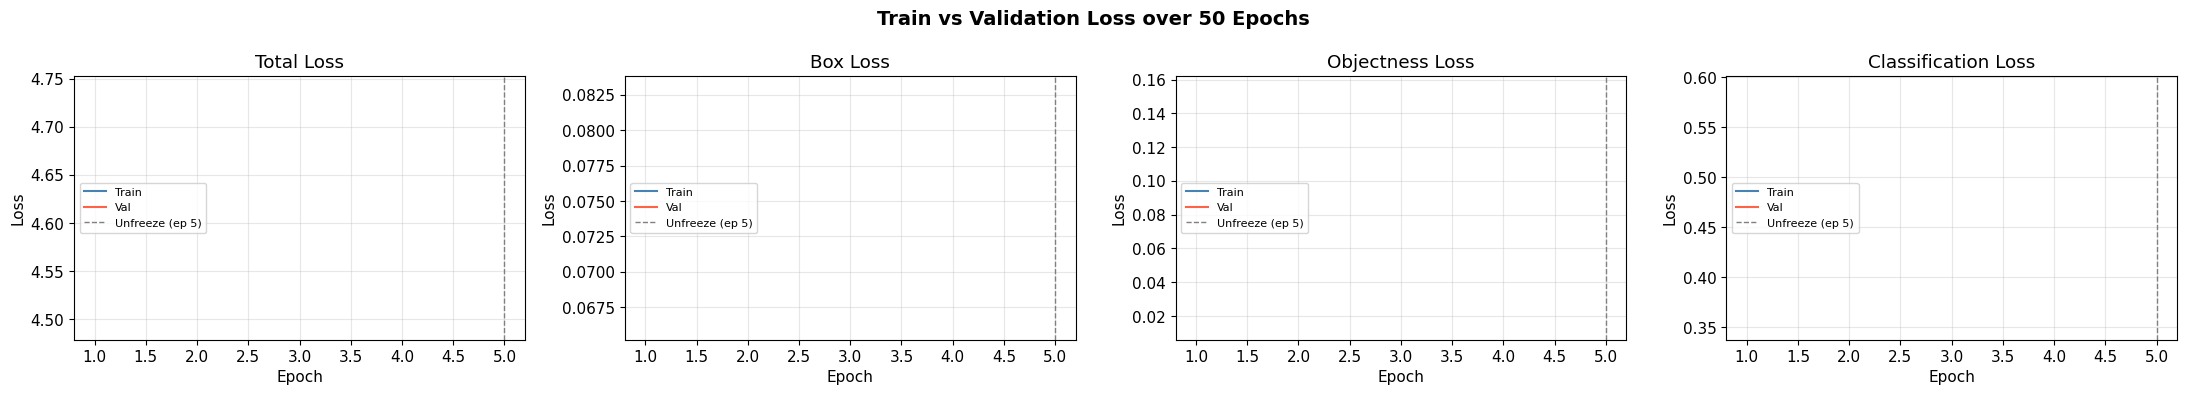

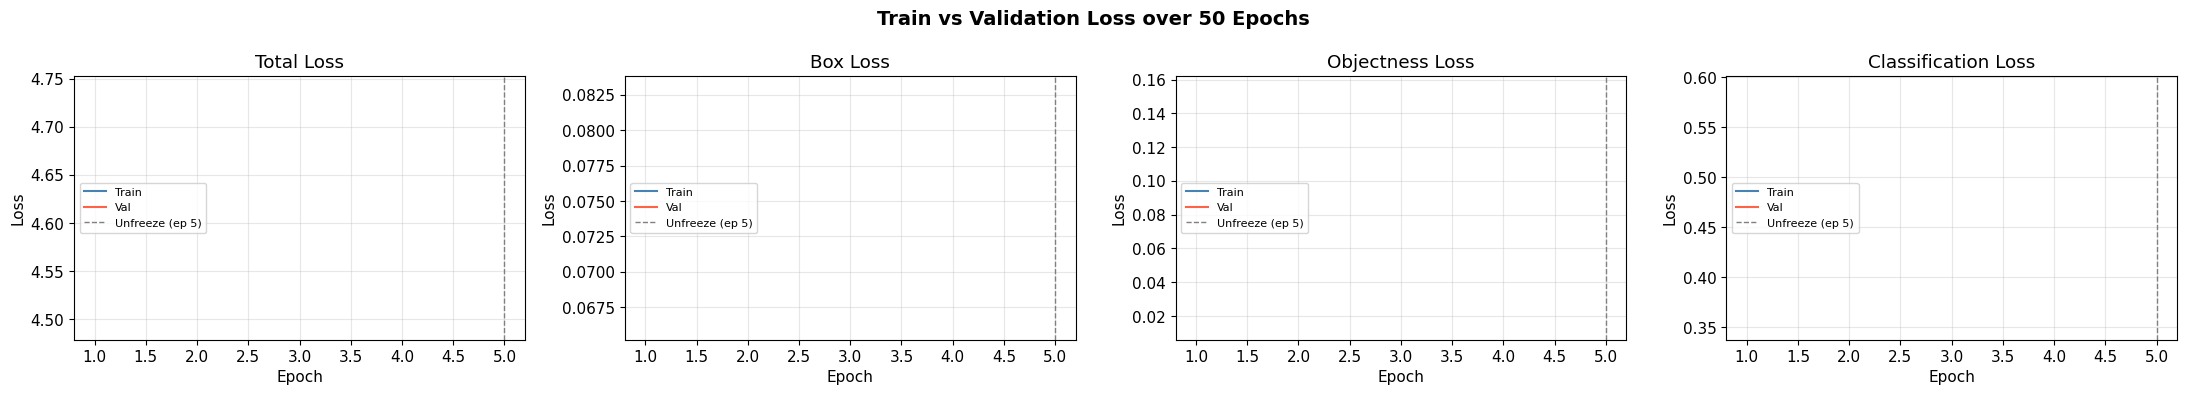

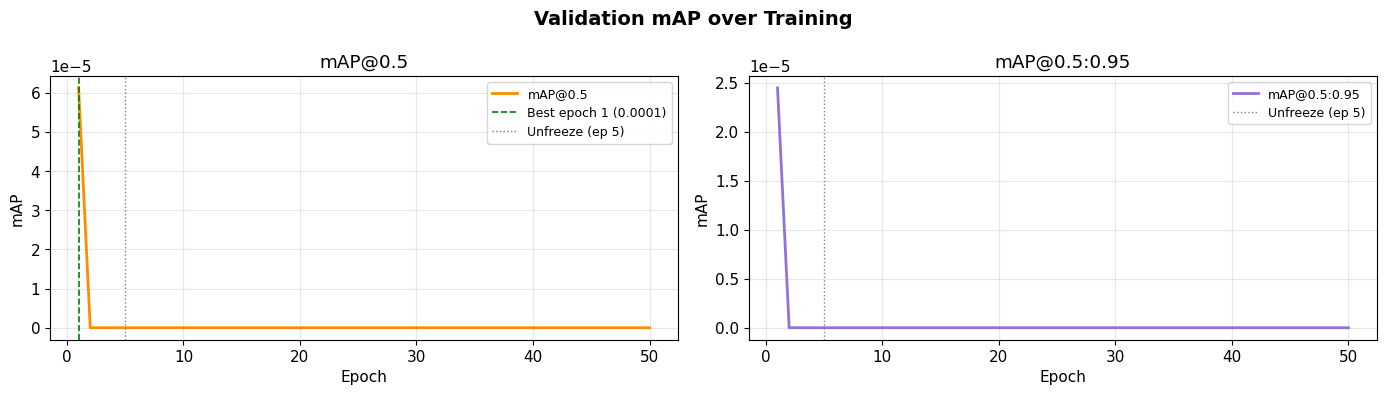

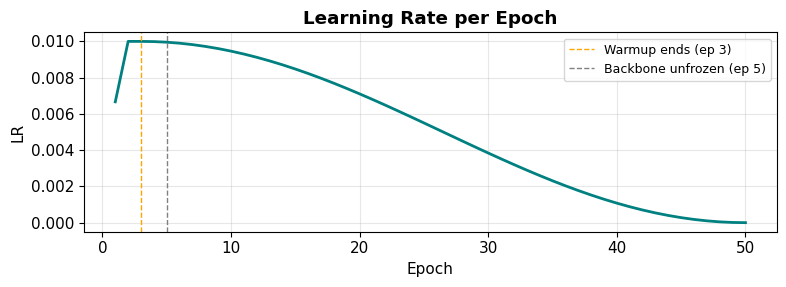

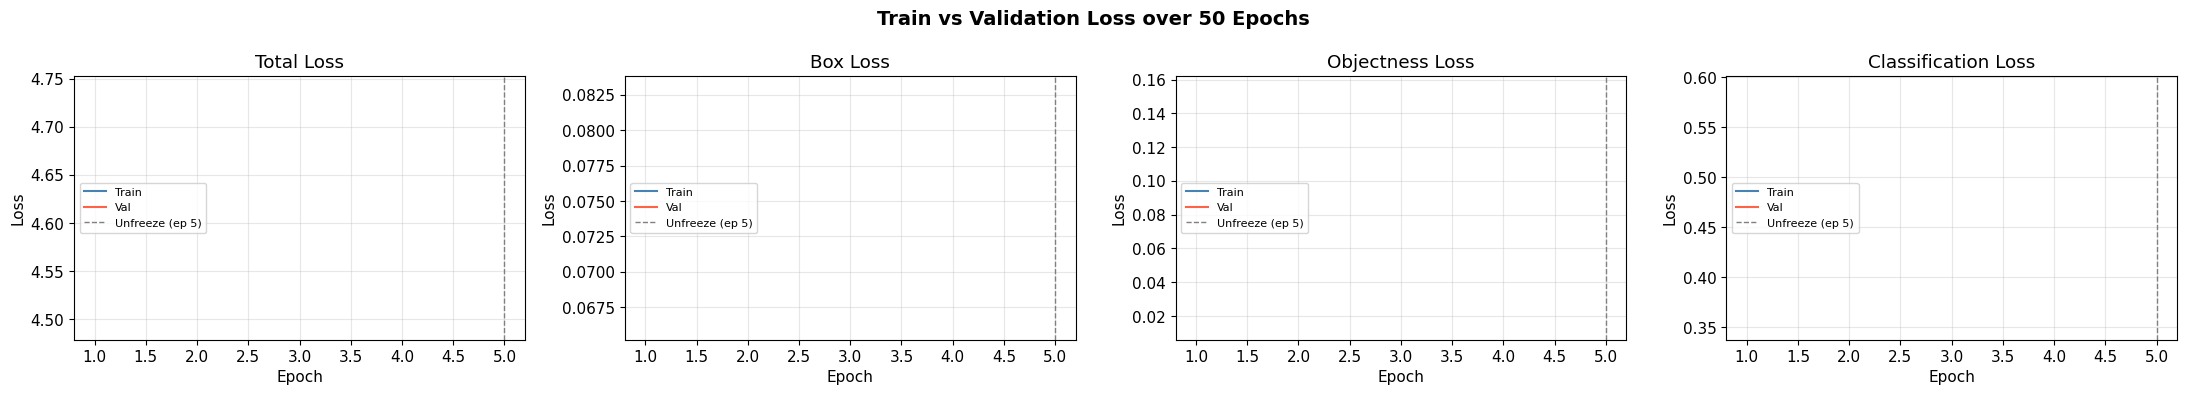

In [29]:
epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
fig.suptitle('Train vs Validation Loss over 50 Epochs', fontsize=14, fontweight='bold')

pairs = [
    ('Total Loss',          'train_loss', 'val_loss'),
    ('Box Loss',            'train_box',  'val_box'),
    ('Objectness Loss',     'train_obj',  'val_obj'),
    ('Classification Loss', 'train_cls',  'val_cls'),
]

for ax, (title, train_key, val_key) in zip(axes, pairs):
    ax.plot(epochs, history[train_key], label='Train', color='steelblue', linewidth=1.5)
    ax.plot(epochs, history[val_key],   label='Val',   color='tomato',    linewidth=1.5)
    ax.axvline(FREEZE_EPOCHS, color='gray', linestyle='--', linewidth=1,
               label=f'Unfreeze (ep {FREEZE_EPOCHS})')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# 9. mAP@0.5 Curve

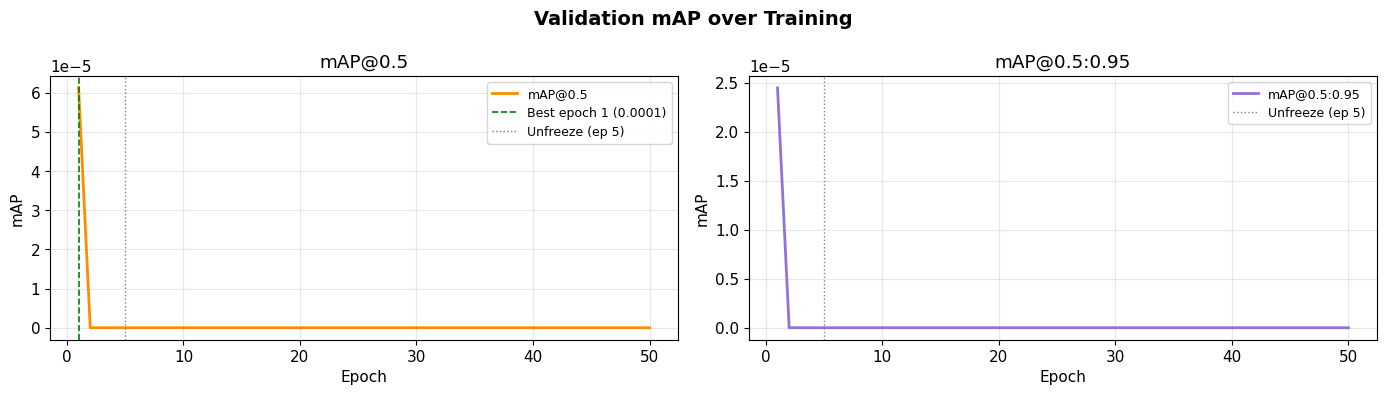


Baseline  mAP@0.5 (no training) : ~0.0005
Best val  mAP@0.5 (epoch  1)    : 0.0001
Final val mAP@0.5 (epoch 50)    : 0.0000


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Validation mAP over Training', fontsize=14, fontweight='bold')

# mAP@0.5
ax = axes[0]
ax.plot(epochs, history['val_map50'], color='darkorange', linewidth=2, label='mAP@0.5')
ax.axvline(best_epoch, color='green', linestyle='--', linewidth=1.2,
           label=f'Best epoch {best_epoch} ({best_map50:.4f})')
ax.axvline(FREEZE_EPOCHS, color='gray', linestyle=':', linewidth=1,
           label=f'Unfreeze (ep {FREEZE_EPOCHS})')
ax.set_title('mAP@0.5')
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# mAP@0.5:0.95
ax = axes[1]
ax.plot(epochs, history['val_map'], color='mediumpurple', linewidth=2, label='mAP@0.5:0.95')
ax.axvline(FREEZE_EPOCHS, color='gray', linestyle=':', linewidth=1,
           label=f'Unfreeze (ep {FREEZE_EPOCHS})')
ax.set_title('mAP@0.5:0.95')
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nBaseline  mAP@0.5 (no training) : ~0.0005')
print(f'Best val  mAP@0.5 (epoch {best_epoch:2d})    : {best_map50:.4f}')
print(f'Final val mAP@0.5 (epoch {NUM_EPOCHS})    : {history["val_map50"][-1]:.4f}')

---
# 10. Learning Rate Schedule (Recorded)

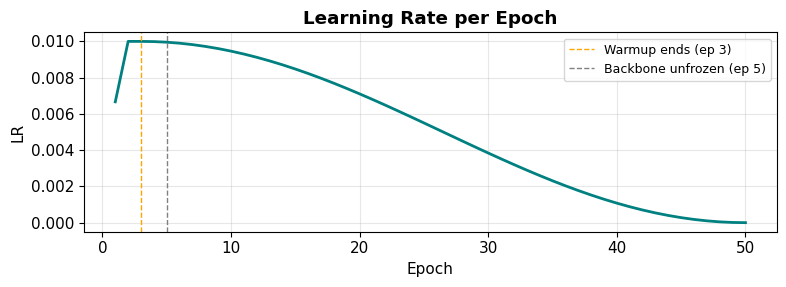

In [31]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(epochs, history['lr'], color='teal', linewidth=2)
ax.axvline(WARMUP_EPOCHS,  color='orange', linestyle='--', linewidth=1, label=f'Warmup ends (ep {WARMUP_EPOCHS})')
ax.axvline(FREEZE_EPOCHS,  color='gray',   linestyle='--', linewidth=1, label=f'Backbone unfrozen (ep {FREEZE_EPOCHS})')
ax.set_title('Learning Rate per Epoch', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('LR')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 11. Predictions on Validation Images (Best Checkpoint)

Load `best.pt` and visualize predictions side-by-side with ground truth on the first
8 validation images.

In [33]:
# Load best weights
model.load_state_dict(torch.load(BEST_PT, map_location=device))
model.eval()
print(f'Loaded best.pt  (epoch {best_epoch}, mAP@0.5 = {best_map50:.4f})')

Loaded best.pt  (epoch 1, mAP@0.5 = 0.0001)


In [34]:
def draw_boxes(ax, img_np, boxes_norm, labels, title, is_pred=False, scores=None):
    """Draw YOLO-format (normalized xywh) boxes on an axis."""
    h, w = img_np.shape[:2]
    ax.imshow(img_np)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
    for i, (box, cls) in enumerate(zip(boxes_norm, labels)):
        cls = int(cls)
        xc, yc, bw, bh = box[0]*w, box[1]*h, box[2]*w, box[3]*h
        x1, y1 = xc - bw/2, yc - bh/2
        rect = patches.Rectangle((x1, y1), bw, bh, linewidth=1.5,
                                  edgecolor=CLASS_COLORS[cls], facecolor='none')
        ax.add_patch(rect)
        label = CLASS_NAMES[cls]
        if is_pred and scores is not None:
            label += f' {scores[i]:.2f}'
        ax.text(x1, y1 - 2, label, fontsize=7, color='white',
                bbox=dict(facecolor=CLASS_COLORS[cls], alpha=0.8, pad=1, edgecolor='none'))


N_VIS = 8   # number of val images to show
val_imgs_vis  = []
val_preds_vis = []
val_gts_vis   = []

with torch.no_grad():
    for imgs, targets, _ in val_loader:
        imgs_dev = imgs.to(device).float()
        preds    = non_max_suppression(model(imgs_dev)[0], conf_thres=0.25, iou_thres=0.45)
        for b in range(len(imgs)):
            if len(val_imgs_vis) >= N_VIS:
                break
            img_np = imgs[b].permute(1,2,0).cpu().numpy()
            val_imgs_vis.append(img_np)

            # Ground truth (normalized xywh)
            mask = targets[:, 0] == b
            gt   = targets[mask][:, 1:].cpu()
            val_gts_vis.append(gt)

            # Predictions → convert xyxy pixel to xywh normalized
            p = preds[b]
            if p is not None and len(p):
                h, w = img_np.shape[:2]
                boxes_xyxy = p[:, :4].cpu()
                cx = (boxes_xyxy[:,0] + boxes_xyxy[:,2]) / 2 / w
                cy = (boxes_xyxy[:,1] + boxes_xyxy[:,3]) / 2 / h
                bw = (boxes_xyxy[:,2] - boxes_xyxy[:,0]) / w
                bh = (boxes_xyxy[:,3] - boxes_xyxy[:,1]) / h
                boxes_norm = torch.stack([cx, cy, bw, bh], dim=1)
                val_preds_vis.append({
                    'boxes' : boxes_norm,
                    'labels': p[:, 5].long().cpu(),
                    'scores': p[:, 4].cpu(),
                })
            else:
                val_preds_vis.append({'boxes': torch.zeros((0,4)),
                                      'labels': torch.zeros(0, dtype=torch.long),
                                      'scores': torch.zeros(0)})
        if len(val_imgs_vis) >= N_VIS:
            break

print(f'Collected {len(val_imgs_vis)} val images for visualization.')

Collected 8 val images for visualization.


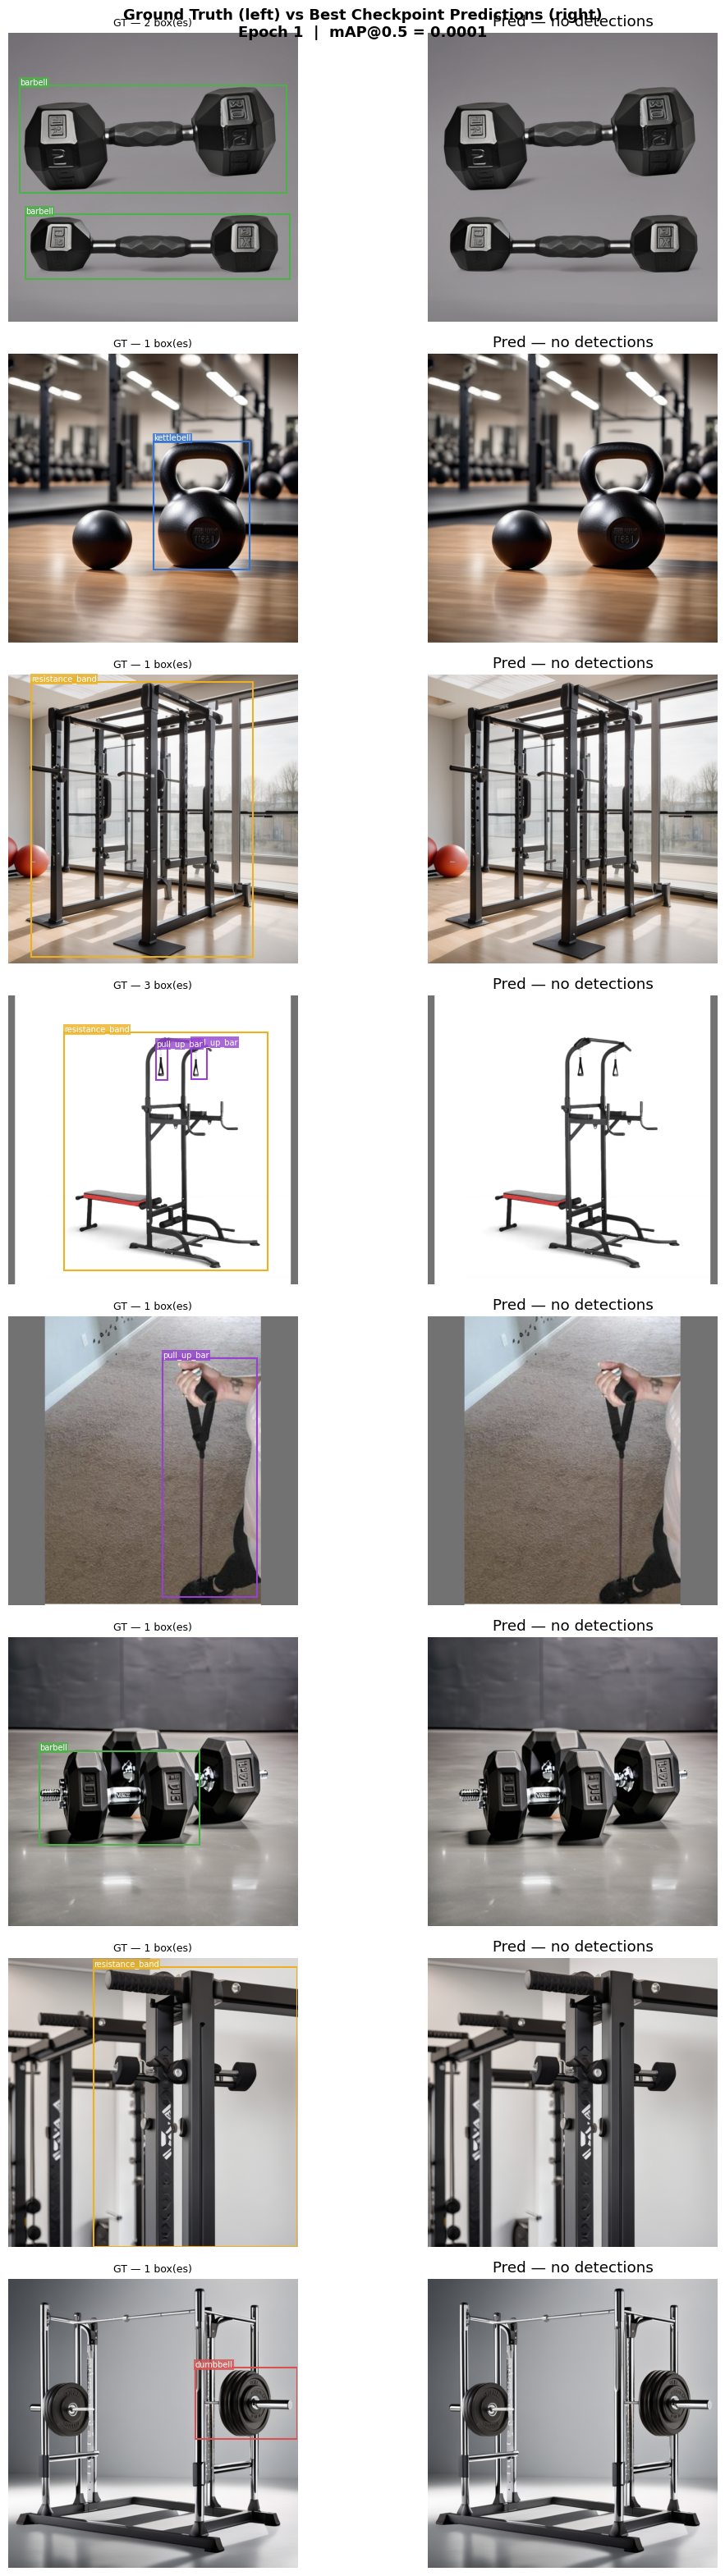

In [35]:
fig, axes = plt.subplots(N_VIS, 2, figsize=(12, 4 * N_VIS))
fig.suptitle(f'Ground Truth (left) vs Best Checkpoint Predictions (right)\n'
             f'Epoch {best_epoch}  |  mAP@0.5 = {best_map50:.4f}',
             fontsize=13, fontweight='bold')

for i in range(N_VIS):
    img_np = val_imgs_vis[i]
    gt     = val_gts_vis[i]       # [N, 5] = [cls, x, y, w, h]
    pred   = val_preds_vis[i]

    # Ground truth
    ax_gt = axes[i][0]
    if len(gt):
        draw_boxes(ax_gt, img_np, gt[:, 1:5].numpy(), gt[:, 0].numpy(),
                   f'GT — {len(gt)} box(es)')
    else:
        ax_gt.imshow(img_np)
        ax_gt.set_title('GT — no annotations')
        ax_gt.axis('off')

    # Prediction
    ax_pr = axes[i][1]
    if len(pred['boxes']):
        draw_boxes(ax_pr, img_np,
                   pred['boxes'].numpy(), pred['labels'].numpy(),
                   f'Pred — {len(pred["boxes"])} detection(s)',
                   is_pred=True, scores=pred['scores'].numpy())
    else:
        ax_pr.imshow(img_np)
        ax_pr.set_title('Pred — no detections')
        ax_pr.axis('off')

plt.tight_layout()
plt.show()

---
# 12. Summary

## Training Results

| Metric | Baseline (no training) | After Fine-Tuning |
|--------|----------------------|-------------------|
| Val mAP@0.5 | ~0.0005 | *see above* |
| Val mAP@0.5:0.95 | ~0.0001 | *see above* |
| Val Total Loss | ~28.0 | *see above* |

## Training Strategy
- **SGD** — lr=0.01, momentum=0.937, weight_decay=5e-4, Nesterov
- **LR Schedule** — 3-epoch linear warmup → cosine annealing over 50 epochs
- **Backbone Freezing** — frozen for epochs 1–5, unfrozen from epoch 6 onward
- **Augmentation** — HSV jitter, random horizontal flip (training only)
- **Loss** — YOLOv7 `ComputeLoss` (CIoU box + BCE obj + BCE cls)
- **Checkpoint** — `best.pt` saved at peak val mAP@0.5

## Next Steps (Phase 3)
- Load `best.pt` and evaluate on the **held-out test set** (first time touching it)
- Per-class AP for all 5 gym equipment classes
- Confusion matrix, Precision-Recall curves
- Side-by-side GT vs prediction on test images

---
*End of Project Update #2*  
*Varun Gazala | Mohit Raiyani | Jatinkumar Nabhoya*  
*University of New Haven — Spring 2026*